In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Cargamos los datos crudos desde la carpeta data/raw
df = pd.read_csv('../../data/raw/nhanes_ui_women.csv')

# Mostramos las primeras 5 filas para comprobar que cargó bien
df.head()

,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
0,109266.0,2017-March2020,NaN,29.0,5.0,2.0,37.8,2.0,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,0,none
1,109267.0,2017-March2020,NaN,21.0,2.0,2.0,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
2,109284.0,2017-March2020,NaN,44.0,1.0,2.0,39.1,2.0,NaN,NaN,...,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,1,stress
3,109286.0,2017-March2020,NaN,33.0,5.0,2.0,28.9,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
4,109290.0,2017-March2020,NaN,68.0,4.0,1.0,28.1,1.0,1.0,NaN,...,2.0,2.0,NaN,1.0,1.0,2.0,2.0,1.0,1,urge


In [76]:
# Ver cuántas filas y columnas tiene el dataset
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

# Ver información general de las columnas (tipos de datos y valores no nulos)
df.info()


El dataset tiene 9074 filas y 27 columnas.

<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_participante            9074 non-null   float64
 1   ciclo_nhanes               9074 non-null   str    
 2   peso_encuesta              4321 non-null   float64
 3   edad_anios                 9074 non-null   float64
 4   etnia                      9074 non-null   float64
 5   pais_nacimiento            9067 non-null   float64
 6   imc                        7620 non-null   float64
 7   dx_hipertension            9074 non-null   float64
 8   medicacion_hta_cicloP      1694 non-null   float64
 9   medicacion_hta_cicloL      1599 non-null   float64
 10  dx_diabetes                9074 non-null   float64
 11  dx_cancer                  9074 non-null   float64
 12  dx_artritis                9074 non-null   float64
 13  fumadora_alguna

In [77]:
# 1. Veamos cuántos duplicados totales hay
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas en el dataset: {duplicados}\n")

# 2. Veamos cuántos valores nulos (faltantes) hay por columna
print("Valores nulos por columna:")
nulos = df.isnull().sum()

# Filtra y muestra solo las columnas que SI tienen nulos, ordenadas de mayor a menor
columnas_con_nulos = nulos[nulos > 0].sort_values(ascending=False)
print(columnas_con_nulos)


Número de filas duplicadas en el dataset: 0

Valores nulos por columna:
ui_urgencia_frecuencia       7724
medicacion_hta_cicloL        7475
medicacion_hta_cicloP        7380
ui_esfuerzo_frecuencia       7339
ui_molestia_percibida        6706
ui_cantidad                  5522
ui_otro_tipo_presente        5020
ui_impacto_actividades       4861
peso_encuesta                4753
actividad_fisica_vigorosa    4321
ui_urgencia_presente         2190
ui_esfuerzo_presente         2185
ui_frecuencia                2180
imc                          1454
nivel_pobreza_familiar        905
pais_nacimiento                 7
fumadora_alguna_vez             6
dtype: int64


/var/folders/1p/w3s14y4d6h73sf2yqfjwgs2w0000gn/T/ipykernel_66685/428606414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


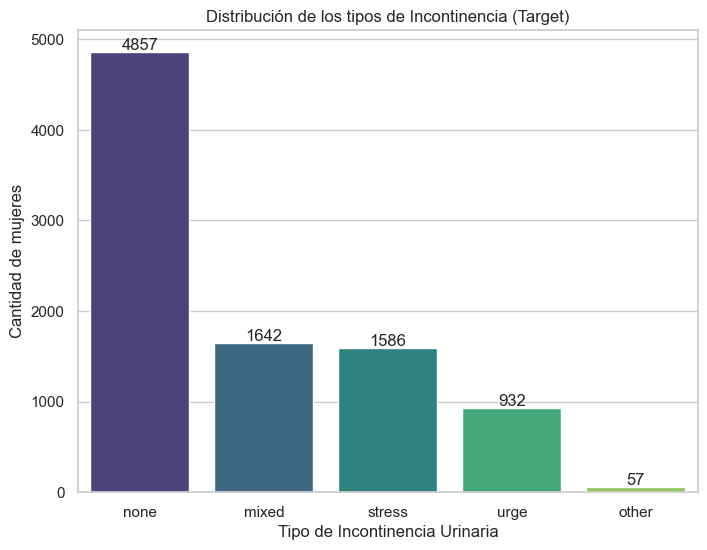


Porcentaje de cada clase en el target:
target_tipo_ui
none      53.53
mixed     18.10
stress    17.48
urge      10.27
other      0.63
Name: proportion, dtype: float64


In [78]:
# Gráfico de barras para ver la distribución de la variable objetivo (target)
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df, 
    x='target_tipo_ui', 
    order=df['target_tipo_ui'].value_counts().index,
    palette='viridis' # Le damos un poco de color
)

# Añadimos titulo y etiquetas a los ejes
plt.title('Distribución de los tipos de Incontinencia (Target)')
plt.xlabel('Tipo de Incontinencia Urinaria')
plt.ylabel('Cantidad de mujeres')

# Esto añade el numerito exacto encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show() # Mostrar el gráfico

# También los imprimimos como porcentajes para tener el dato exacto
print("\nPorcentaje de cada clase en el target:")
print(round(df['target_tipo_ui'].value_counts(normalize=True) * 100, 2))


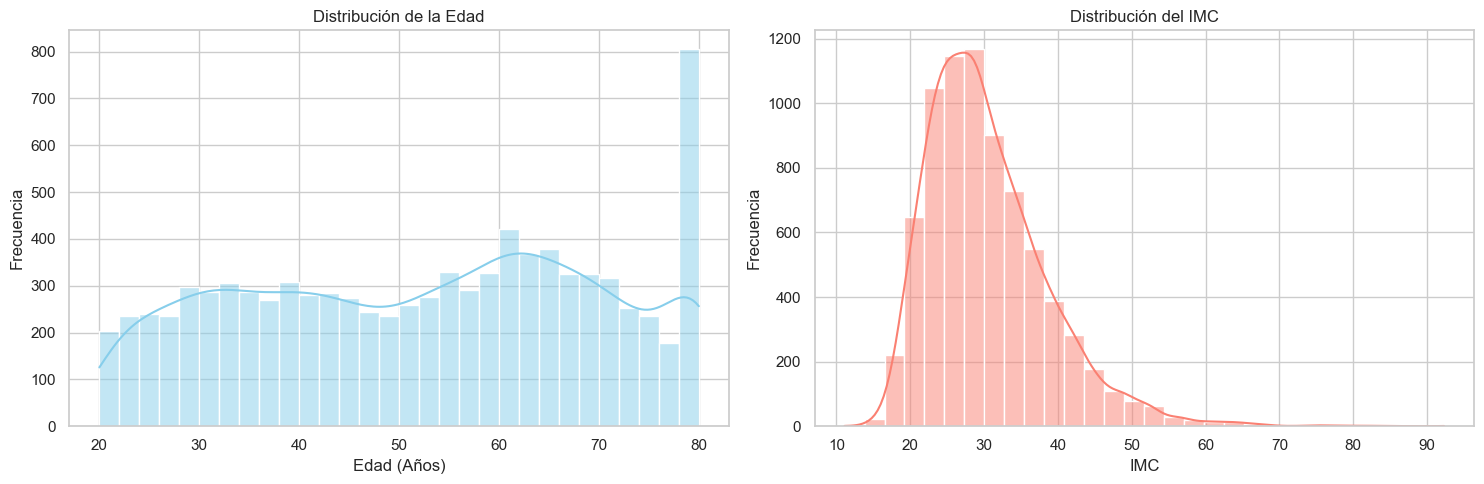


Estadísticas descriptivas básicas para Edad e IMC:


,edad_anios,imc
count,9074.000000,7620.000000
mean,52.077584,30.471325
std,17.627592,8.212430
min,20.000000,11.100000
25%,37.000000,24.600000
50%,54.000000,29.000000
75%,67.000000,34.800000
max,80.000000,92.300000


In [79]:
# Hacemos un lienzo con dos subgráficos (uno al lado del otro)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Histograma de la Edad
sns.histplot(data=df, x='edad_anios', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de la Edad')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Histograma del IMC
sns.histplot(data=df, x='imc', bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución del IMC')
axes[1].set_xlabel('IMC')
axes[1].set_ylabel('Frecuencia')

# Mostramos ambos gráficos juntos
plt.tight_layout()
plt.show()

# También imprimimos un pequeño resumen estadístico (media, medias, minimo, máximo) de ellas
print("\nEstadísticas descriptivas básicas para Edad e IMC:")
df[['edad_anios', 'imc']].describe()


/var/folders/1p/w3s14y4d6h73sf2yqfjwgs2w0000gn/T/ipykernel_66685/80007346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_tipo_ui', y='edad_anios', ax=axes[0], palette='Set2')
/var/folders/1p/w3s14y4d6h73sf2yqfjwgs2w0000gn/T/ipykernel_66685/80007346.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_tipo_ui', y='imc', ax=axes[1], palette='Set2')


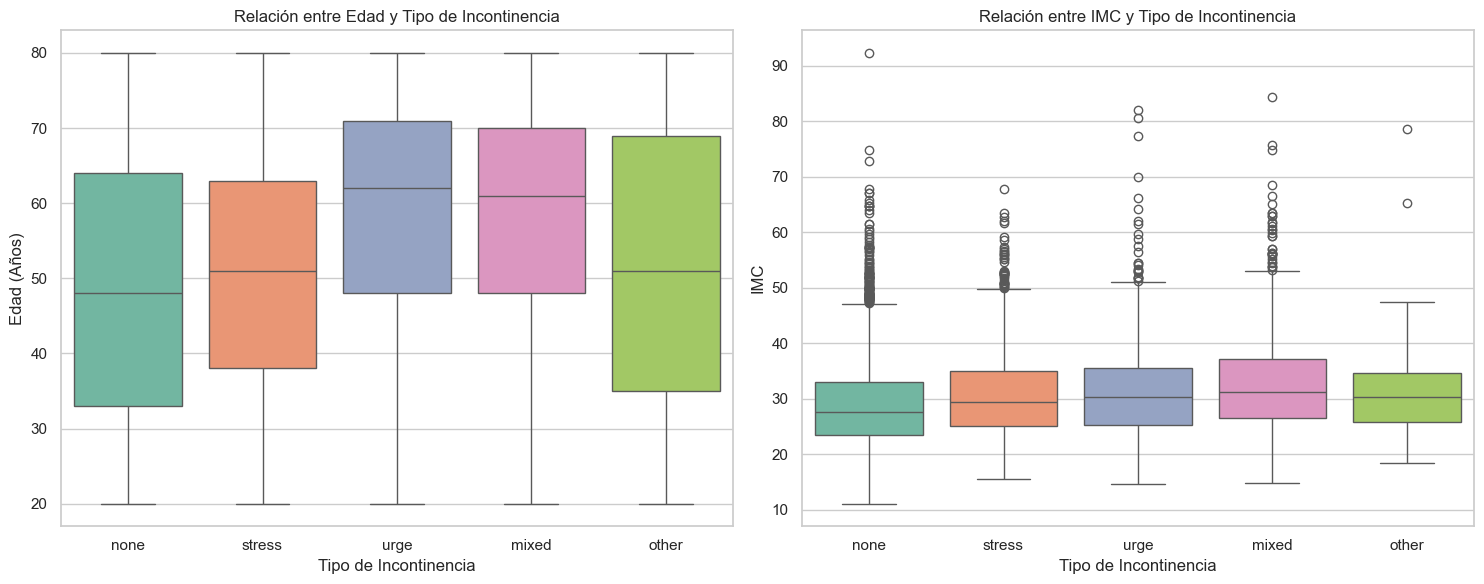

In [80]:
# Hacemos un lienzo con dos subgráficos (uno al lado del otro)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Edad vs Tipo de Incontinencia (Boxplot)
sns.boxplot(data=df, x='target_tipo_ui', y='edad_anios', ax=axes[0], palette='Set2')
axes[0].set_title('Relación entre Edad y Tipo de Incontinencia')
axes[0].set_xlabel('Tipo de Incontinencia')
axes[0].set_ylabel('Edad (Años)')

# Gráfico 2: IMC vs Tipo de Incontinencia (Boxplot)
sns.boxplot(data=df, x='target_tipo_ui', y='imc', ax=axes[1], palette='Set2')
axes[1].set_title('Relación entre IMC y Tipo de Incontinencia')
axes[1].set_xlabel('Tipo de Incontinencia')
axes[1].set_ylabel('IMC')

# Ajustamos para que no se superpongan y mostramos
plt.tight_layout()
plt.show()


In [81]:
# Definimos los valores anómalos típicos del CDC
cdc_missings = [7.0, 9.0, 77.0, 99.0]
vars_to_check = ['etnia', 'pais_nacimiento', 'dx_hipertension', 'medicacion_hta_cicloP',
                 'medicacion_hta_cicloL', 'dx_diabetes', 'dx_cancer', 'dx_artritis',
                 'fumadora_alguna_vez', 'actividad_fisica_vigorosa', 'nivel_pobreza_familiar',
                 'ui_frecuencia', 'ui_cantidad', 'ui_esfuerzo_presente', 'ui_esfuerzo_frecuencia',
                 'ui_urgencia_presente', 'ui_urgencia_frecuencia', 'ui_otro_tipo_presente',
                 'ui_molestia_percibida', 'ui_impacto_actividades']

print("Conteo de posibles códigos de missing del CDC (7, 9, 77, 99) por variable:\n")

# Para cada columna, contamos cuántos valores coinciden con esos códigos especiales
for col in vars_to_check:
    if col in df.columns:
        count = df[col].isin(cdc_missings).sum()
        if count > 0:
            print(f"- {col}: {count} casos anómalos encontrados")


Conteo de posibles códigos de missing del CDC (7, 9, 77, 99) por variable:

- pais_nacimiento: 5 casos anómalos encontrados
- dx_hipertension: 10 casos anómalos encontrados
- medicacion_hta_cicloL: 2 casos anómalos encontrados
- dx_diabetes: 5 casos anómalos encontrados
- dx_cancer: 8 casos anómalos encontrados
- dx_artritis: 27 casos anómalos encontrados
- fumadora_alguna_vez: 8 casos anómalos encontrados
- nivel_pobreza_familiar: 281 casos anómalos encontrados
- ui_frecuencia: 7 casos anómalos encontrados
- ui_cantidad: 3 casos anómalos encontrados
- ui_esfuerzo_presente: 7 casos anómalos encontrados
- ui_esfuerzo_frecuencia: 1 casos anómalos encontrados
- ui_urgencia_presente: 8 casos anómalos encontrados
- ui_urgencia_frecuencia: 1 casos anómalos encontrados
- ui_otro_tipo_presente: 6 casos anómalos encontrados
- ui_impacto_actividades: 2 casos anómalos encontrados


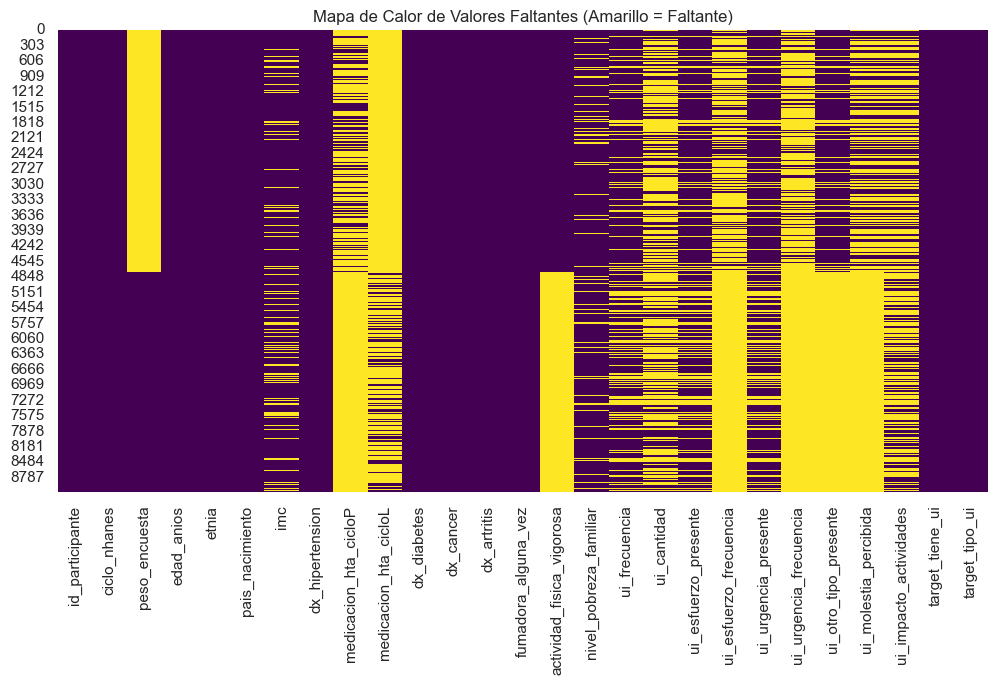


Clasificación de variables por % de valores faltantes:

🟢 Menos del 5% de nulos:
pais_nacimiento        0.077143
fumadora_alguna_vez    0.066123
id_participante        0.000000
ciclo_nhanes           0.000000
edad_anios             0.000000
etnia                  0.000000
dx_hipertension        0.000000
dx_diabetes            0.000000
dx_cancer              0.000000
dx_artritis            0.000000
target_tiene_ui        0.000000
target_tipo_ui         0.000000
dtype: float64

🟡 Entre 5% y 20% de nulos:
imc                       16.023804
nivel_pobreza_familiar     9.973551
dtype: float64

🔴 Más del 20% de nulos:
ui_urgencia_frecuencia       85.122328
medicacion_hta_cicloL        82.378223
medicacion_hta_cicloP        81.331276
ui_esfuerzo_frecuencia       80.879436
ui_molestia_percibida        73.903460
ui_cantidad                  60.855191
ui_otro_tipo_presente        55.322901
ui_impacto_actividades       53.570641
peso_encuesta                52.380428
actividad_fisica_vigorosa   

In [82]:
# 1. Mapa de Calor (Heatmap) de los Nulos
plt.figure(figsize=(12, 6))
# 'isnull()' devuelve True si el dato falta. El heatmap lo dibuja en blanco/negro.
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Faltantes (Amarillo = Faltante)')
plt.show()

# 2. Clasificación del porcentaje de Nulos
print("\nClasificación de variables por % de valores faltantes:\n")
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

print("🟢 Menos del 5% de nulos:")
print(porcentaje_nulos[porcentaje_nulos < 5].sort_values(ascending=False))

print("\n🟡 Entre 5% y 20% de nulos:")
print(porcentaje_nulos[(porcentaje_nulos >= 5) & (porcentaje_nulos <= 20)].sort_values(ascending=False))

print("\n🔴 Más del 20% de nulos:")
print(porcentaje_nulos[porcentaje_nulos > 20].sort_values(ascending=False))


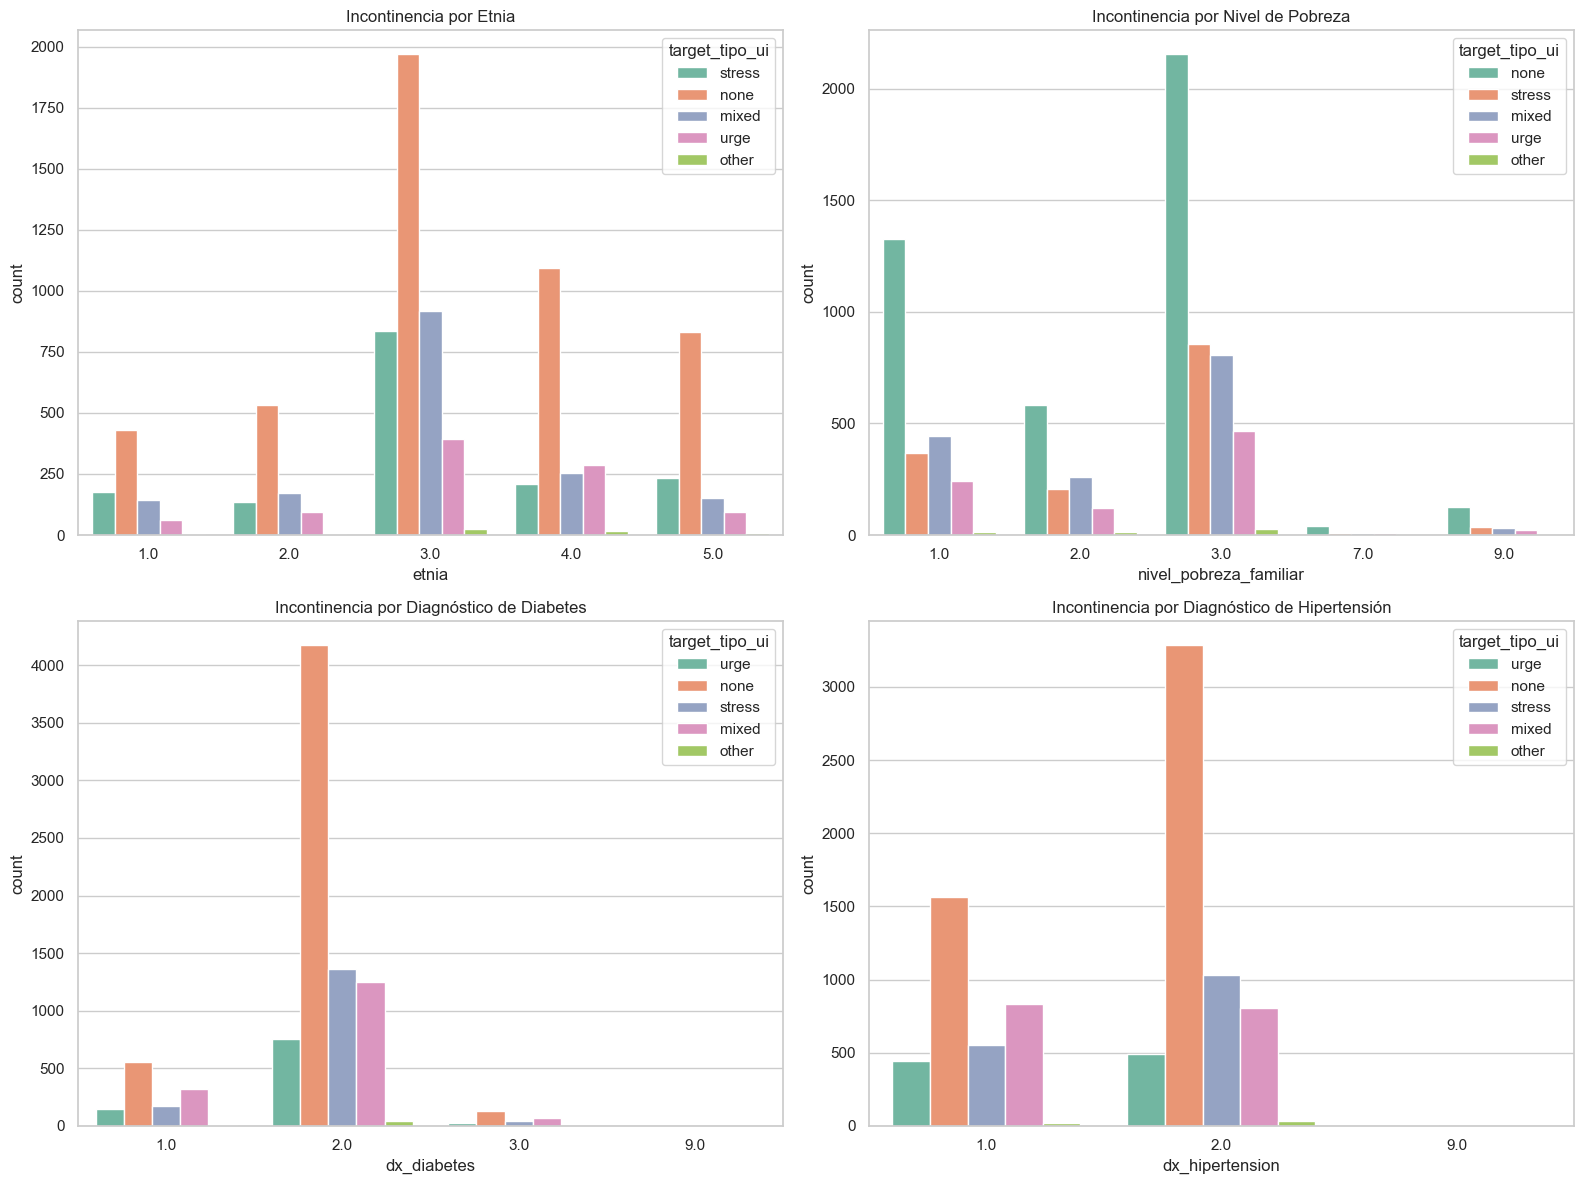

In [83]:
# Hacemos un panel grande para 4 gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Etnia vs Target
sns.countplot(data=df, x='etnia', hue='target_tipo_ui', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Incontinencia por Etnia')

# 2. Nivel de Pobreza vs Target
sns.countplot(data=df, x='nivel_pobreza_familiar', hue='target_tipo_ui', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Incontinencia por Nivel de Pobreza')

# 3. Diabetes vs Target
sns.countplot(data=df, x='dx_diabetes', hue='target_tipo_ui', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Incontinencia por Diagnóstico de Diabetes')

# 4. Hipertensión vs Target
sns.countplot(data=df, x='dx_hipertension', hue='target_tipo_ui', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Incontinencia por Diagnóstico de Hipertensión')

plt.tight_layout()
plt.show()


## Limpieza de Datos (ETL)

### Paso 1 del ETL: Fusionar la clase "other" en "urge"

In [84]:
# 1. Veamos cuántos casos hay antes del cambio
print("Antes de la fusión:")
print(df['target_tipo_ui'].value_counts())

# 2. Reemplazamos 'other' por 'urge'
df['target_tipo_ui'] = df['target_tipo_ui'].replace('other', 'urge')

print("\n----------------------\n")

# 3. Veamos cómo quedó después del cambio
print("Después de la fusión (Verificamos que queden 4 clases):")
print(df['target_tipo_ui'].value_counts())


Antes de la fusión:
target_tipo_ui
none      4857
mixed     1642
stress    1586
urge       932
other       57
Name: count, dtype: int64

----------------------

Después de la fusión (Verificamos que queden 4 clases):
target_tipo_ui
none      4857
mixed     1642
stress    1586
urge       989
Name: count, dtype: int64


### Paso 2 del ETL: Quitar las variables trampa (Data Leakage) y los Códigos CDC

In [85]:
# 1. Variables a eliminar por Fuga de Información ("Hacer trampa")
cols_fuga_info = [
    'ui_frecuencia', 'ui_cantidad', 'ui_esfuerzo_presente', 
    'ui_esfuerzo_frecuencia', 'ui_urgencia_presente', 'ui_urgencia_frecuencia', 
    'ui_otro_tipo_presente', 'ui_molestia_percibida', 'ui_impacto_actividades'
]

# Borramos esas columnas del dataframe
df.drop(columns=cols_fuga_info, inplace=True, errors='ignore')
print(f"Borradas {len(cols_fuga_info)} columnas de 'Fuga de Información'.")

# 2. Reemplazamos los códigos especiales del CDC por valores nulos matemáticos (NaN)
vars_cdc = ['etnia', 'pais_nacimiento', 'dx_hipertension', 'medicacion_hta_cicloP',
            'medicacion_hta_cicloL', 'dx_diabetes', 'dx_cancer', 'dx_artritis',
            'fumadora_alguna_vez', 'actividad_fisica_vigorosa', 'nivel_pobreza_familiar']

# Sustituimos el 7, 9, 77 y 99 por np.nan
for col in vars_to_check:
    if col in df.columns:
        df[col] = df[col].replace(cdc_missings, np.nan)

print("Códigos CDC clasificados y convertidos a valores Nulos Reales (NaN).")


Borradas 9 columnas de 'Fuga de Información'.
Códigos CDC clasificados y convertidos a valores Nulos Reales (NaN).


### Paso 3 del ETL: Rellenar (Imputar) los Nulos

In [86]:
from sklearn.impute import SimpleImputer

# 1. Variables Numéricas (Llenamos con la Mediana)
cols_numericas = ['imc', 'edad_anios']
imputer_num = SimpleImputer(strategy='median')
df[cols_numericas] = imputer_num.fit_transform(df[cols_numericas])

# 2. Variables Categóricas (Llenamos con el valor más frecuente / Moda)
cols_categoricas = df.columns.drop(cols_numericas + ['target_tiene_ui', 'target_tipo_ui'])
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cols_categoricas] = imputer_cat.fit_transform(df[cols_categoricas])

# 3. Comprobación de seguridad
print("Valores nulos restantes en el dataset:")
print(df.isnull().sum().sum())  # Debería dar 0


Valores nulos restantes en el dataset:
0


### Traducir a números (Encoding) y Guardar

In [87]:
from sklearn.preprocessing import LabelEncoder

# 1. Hacemos una lista solo con las columnas que tienen texto (tipo 'object')
cols_texto = df.select_dtypes(include=['object']).columns

# 2. Convertimos el texto a números (ej: 'none' -> 0, 'stress' -> 1)
le = LabelEncoder()
for col in cols_texto:
    df[col] = le.fit_transform(df[col].astype(str))

# 3. Guardamos el dataset final limpio y preparado en la carpeta processed
df.to_csv('../../data/processed/nhanes_clean.csv', index=False)

print("¡Dataset codificado y guardado con éxito como 'nhanes_clean.csv' en la carpeta data/processed!")
print(f"El dataset final tiene {df.shape[0]} filas y {df.shape[1]} columnas listas para Machine Learning.")


¡Dataset codificado y guardado con éxito como 'nhanes_clean.csv' en la carpeta data/processed!
El dataset final tiene 9074 filas y 18 columnas listas para Machine Learning.


/var/folders/1p/w3s14y4d6h73sf2yqfjwgs2w0000gn/T/ipykernel_66685/3957330876.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texto = df.select_dtypes(include=['object']).columns
